In [1]:
"""
Clustering Algorithm Comparison for Bengali Coreference Resolution
Author: Zenith
Date: February 2026

PURPOSE: Rigorous head-to-head comparison of 4 clustering algorithms
at cluster-matched thresholds (~3.9 clusters/doc = gold standard).

This addresses the gap in the preliminary study where graph_cc was selected
without a controlled comparison at meaningful cluster counts.

DESIGN:
  - 5 models × 4 algorithms × fine-grained threshold sweep
  - For each model×algorithm, find threshold producing ~3.9 clusters/doc
  - Compare CoNLL F1 at cluster-matched operating points
  - Full BenCoref dataset (122 documents)

MODELS (5 selected for fine-tuning):
  1. mBERT (multilingual baseline)
  2. BanglaBERT-Base (Bengali-specific)
  3. RemBERT (low-resource specialist)
  4. MuRIL-Large (Indic-focused)
  5. BERT-Base-Uncased (no-Bengali control)

ALGORITHMS:
  1. Graph-based Connected Components
  2. Greedy Forward (Centroid)
  3. Greedy Backward (Best-match)
  4. Hierarchical Agglomerative (Average linkage)
"""

# Suppress warnings
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"
import warnings
warnings.filterwarnings("ignore")

# Core imports
import json
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Dict, List, Tuple, Optional
from dataclasses import dataclass
from collections import defaultdict
from datetime import datetime
import time
import gc

# ML imports
from transformers import AutoModel, AutoTokenizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import AgglomerativeClustering
from scipy.optimize import linear_sum_assignment
import networkx as nx

# Reproducibility
def set_seed(seed: int = 42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# Plot style
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
sns.set_style("whitegrid")

# Environment
print("=" * 80)
print("CLUSTERING ALGORITHM COMPARISON")
print("=" * 80)
print(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
print("=" * 80)

CLUSTERING ALGORITHM COMPARISON
Timestamp: 2026-02-03 15:21:43
PyTorch: 2.9.0+cu128
CUDA: True
GPU: NVIDIA L4
GPU Memory: 23.58 GB


In [2]:
"""
Cell 1: Define 5 models selected for fine-tuning experiments.
"""

@dataclass
class ModelConfig:
    name: str
    hf_model_id: str
    category: str
    hidden_dim: int

MODELS = [
    ModelConfig("mBERT", "google-bert/bert-base-multilingual-cased", "multilingual", 768),
    ModelConfig("BanglaBERT-Base", "csebuetnlp/banglabert", "bengali-specific", 768),
    ModelConfig("RemBERT", "google/rembert", "low-resource-specialist", 1152),
    ModelConfig("MuRIL-Large", "google/muril-large-cased", "indic-focused", 1024),
    ModelConfig("BERT-Base-Uncased", "google-bert/bert-base-uncased", "no-bengali-control", 768),
]

print(f"Models to evaluate: {len(MODELS)}")
for m in MODELS:
    print(f"  {m.name:<20s} ({m.category}, dim={m.hidden_dim})")
print("\u2713 Models defined")

Models to evaluate: 5
  mBERT                (multilingual, dim=768)
  BanglaBERT-Base      (bengali-specific, dim=768)
  RemBERT              (low-resource-specialist, dim=1152)
  MuRIL-Large          (indic-focused, dim=1024)
  BERT-Base-Uncased    (no-bengali-control, dim=768)
✓ Models defined


In [3]:
"""
Cell 2: Load BenCoref dataset (122 documents, 4 domains).
"""

DATA_DIR = Path("/teamspace/studios/this_studio/train_files")

def load_bencoref_dataset(data_dir: Path) -> List[Dict]:
    documents = []
    domain_files = {
        'biography': 'biography.json',
        'descriptive': 'descriptive.json',
        'novel': 'novel.json',
        'story': 'story.json'
    }
    
    for domain, filename in domain_files.items():
        filepath = data_dir / filename
        if not filepath.exists():
            print(f"  Warning: {filename} not found")
            continue
        
        with open(filepath, 'r', encoding='utf-8') as f:
            data = json.load(f)
        
        doc_indices = list(data['id'].keys())
        for doc_idx in doc_indices:
            doc_id = data['id'][doc_idx]
            sentences = data['sentences'][doc_idx]
            raw_clusters = data['mention_clusters'][doc_idx]
            
            all_mentions = []
            clusters = []
            mention_to_idx = {}
            
            for cluster in raw_clusters:
                cluster_mention_indices = []
                for mention in cluster:
                    sent_idx, start, end = mention
                    mention_key = (sent_idx, start, end)
                    if mention_key not in mention_to_idx:
                        mention_idx = len(all_mentions)
                        mention_to_idx[mention_key] = mention_idx
                        all_mentions.append({
                            'sentence_idx': sent_idx,
                            'start': start,
                            'end': end
                        })
                    else:
                        mention_idx = mention_to_idx[mention_key]
                    cluster_mention_indices.append(mention_idx)
                clusters.append(cluster_mention_indices)
            
            documents.append({
                'id': doc_id,
                'domain': domain,
                'sentences': sentences,
                'mentions': all_mentions,
                'clusters': clusters
            })
    
    return documents

bencoref_data = load_bencoref_dataset(DATA_DIR)
print(f"Loaded {len(bencoref_data)} documents")

# Gold cluster stats
gold_clusters_per_doc = [len(doc['clusters']) for doc in bencoref_data]
gold_avg = np.mean(gold_clusters_per_doc)
print(f"Gold clusters/doc: mean={gold_avg:.2f}, median={np.median(gold_clusters_per_doc):.1f}")

domain_counts = defaultdict(int)
for doc in bencoref_data:
    domain_counts[doc['domain']] += 1
for domain, count in sorted(domain_counts.items()):
    print(f"  {domain}: {count} docs")

GOLD_TARGET_CLUSTERS = gold_avg
print(f"\nTarget clusters/doc for matching: {GOLD_TARGET_CLUSTERS:.2f}")
print("\u2713 Data loaded")

Loaded 122 documents
Gold clusters/doc: mean=3.85, median=3.0
  biography: 17 docs
  descriptive: 36 docs
  novel: 13 docs
  story: 56 docs

Target clusters/doc for matching: 3.85
✓ Data loaded


In [4]:
"""
Cell 3: Coreference evaluation metrics (MUC, B\u00b3, CEAFe, CoNLL F1).
Same implementation as all other experiment notebooks.
"""

class CorefMetrics:
    @staticmethod
    def muc(gold_clusters, pred_clusters):
        def links(clusters, reference_clusters):
            total_mentions = sum(len(c) for c in clusters)
            total_partitions = 0
            for cluster in clusters:
                cluster_set = set(cluster)
                partitions = sum(1 for ref in reference_clusters if cluster_set & set(ref))
                total_partitions += partitions
            return total_mentions - total_partitions
        
        gold_mentions = sum(len(c) for c in gold_clusters)
        gold_links = gold_mentions - len(gold_clusters)
        recall = links(gold_clusters, pred_clusters) / gold_links if gold_links > 0 else 0.0
        
        pred_mentions = sum(len(c) for c in pred_clusters)
        pred_links = pred_mentions - len(pred_clusters)
        precision = links(pred_clusters, gold_clusters) / pred_links if pred_links > 0 else 0.0
        
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        return precision, recall, f1
    
    @staticmethod
    def b_cubed(gold_clusters, pred_clusters):
        mention_to_gold = {}
        for cluster in gold_clusters:
            cluster_set = frozenset(cluster)
            for mention in cluster:
                mention_to_gold[mention] = cluster_set
        
        mention_to_pred = {}
        for cluster in pred_clusters:
            cluster_set = frozenset(cluster)
            for mention in cluster:
                mention_to_pred[mention] = cluster_set
        
        all_mentions = set(mention_to_gold.keys()) | set(mention_to_pred.keys())
        if not all_mentions:
            return 0.0, 0.0, 0.0
        
        total_precision = 0.0
        total_recall = 0.0
        for mention in all_mentions:
            gold_cluster = mention_to_gold.get(mention, frozenset([mention]))
            pred_cluster = mention_to_pred.get(mention, frozenset([mention]))
            intersection = len(gold_cluster & pred_cluster)
            if len(pred_cluster) > 0:
                total_precision += intersection / len(pred_cluster)
            if len(gold_cluster) > 0:
                total_recall += intersection / len(gold_cluster)
        
        precision = total_precision / len(all_mentions)
        recall = total_recall / len(all_mentions)
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        return precision, recall, f1
    
    @staticmethod
    def ceaf_e(gold_clusters, pred_clusters):
        if not gold_clusters or not pred_clusters:
            return 0.0, 0.0, 0.0
        
        n_gold, n_pred = len(gold_clusters), len(pred_clusters)
        sim_matrix = np.zeros((n_gold, n_pred))
        for i, gc in enumerate(gold_clusters):
            gs = set(gc)
            for j, pc in enumerate(pred_clusters):
                ps = set(pc)
                inter = len(gs & ps)
                if len(gs) + len(ps) > 0:
                    sim_matrix[i, j] = 2 * inter / (len(gs) + len(ps))
        
        row_ind, col_ind = linear_sum_assignment(-sim_matrix)
        total_sim = sim_matrix[row_ind, col_ind].sum()
        
        recall = total_sim / n_gold if n_gold > 0 else 0.0
        precision = total_sim / n_pred if n_pred > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        return precision, recall, f1
    
    @staticmethod
    def evaluate(gold_clusters, pred_clusters):
        gold_non_singleton = [c for c in gold_clusters if len(c) > 1]
        pred_non_singleton = [c for c in pred_clusters if len(c) > 1]
        
        muc_p, muc_r, muc_f1 = CorefMetrics.muc(gold_non_singleton, pred_non_singleton)
        b3_p, b3_r, b3_f1 = CorefMetrics.b_cubed(gold_clusters, pred_clusters)
        ceaf_p, ceaf_r, ceaf_f1 = CorefMetrics.ceaf_e(gold_clusters, pred_clusters)
        conll_f1 = (muc_f1 + b3_f1 + ceaf_f1) / 3
        
        return {
            'MUC_F1': muc_f1 * 100,
            'B3_F1': b3_f1 * 100,
            'CEAF_F1': ceaf_f1 * 100,
            'CoNLL_F1': conll_f1 * 100
        }

# Verify
gold = [[0, 1, 2], [3, 4]]
m = CorefMetrics.evaluate(gold, gold)
print(f"Perfect match: CoNLL F1 = {m['CoNLL_F1']:.1f}% (expected: 100%)")
print("\u2713 Metrics verified")

Perfect match: CoNLL F1 = 100.0% (expected: 100%)
✓ Metrics verified


In [5]:
"""
Cell 4: Four clustering algorithms.
  1. Graph-based Connected Components (transitive closure)
  2. Greedy Forward (centroid-based, left-to-right)
  3. Greedy Backward (best individual match, left-to-right)
  4. Hierarchical Agglomerative (average linkage)
"""

def cluster_graph_cc(similarity_matrix: np.ndarray, threshold: float) -> List[List[int]]:
    """Graph-based Connected Components: edges where sim >= threshold, clusters = components."""
    n = similarity_matrix.shape[0]
    if n == 0: return []
    if n == 1: return [[0]]
    
    G = nx.Graph()
    G.add_nodes_from(range(n))
    for i in range(n):
        for j in range(i + 1, n):
            if similarity_matrix[i, j] >= threshold:
                G.add_edge(i, j)
    return [list(c) for c in nx.connected_components(G)]


def cluster_greedy_forward(similarity_matrix: np.ndarray, threshold: float) -> List[List[int]]:
    """Greedy Forward: compare to cluster centroids, join best if >= threshold."""
    n = similarity_matrix.shape[0]
    if n == 0: return []
    
    clusters = [[0]]
    for i in range(1, n):
        best_cluster_idx = -1
        best_similarity = -1
        for c_idx, cluster in enumerate(clusters):
            centroid_sim = np.mean([similarity_matrix[i, j] for j in cluster])
            if centroid_sim > best_similarity:
                best_similarity = centroid_sim
                best_cluster_idx = c_idx
        if best_similarity >= threshold:
            clusters[best_cluster_idx].append(i)
        else:
            clusters.append([i])
    return clusters


def cluster_greedy_backward(similarity_matrix: np.ndarray, threshold: float) -> List[List[int]]:
    """Greedy Backward: compare to individual mentions, join cluster of best match if >= threshold."""
    n = similarity_matrix.shape[0]
    if n == 0: return []
    
    mention_to_cluster = {0: 0}
    clusters = [[0]]
    for i in range(1, n):
        best_cluster_idx = -1
        best_similarity = -1
        for j in range(i):
            sim = similarity_matrix[i, j]
            if sim > best_similarity:
                best_similarity = sim
                best_cluster_idx = mention_to_cluster[j]
        if best_similarity >= threshold:
            clusters[best_cluster_idx].append(i)
            mention_to_cluster[i] = best_cluster_idx
        else:
            new_idx = len(clusters)
            clusters.append([i])
            mention_to_cluster[i] = new_idx
    return clusters


def cluster_hierarchical_avg(similarity_matrix: np.ndarray, threshold: float) -> List[List[int]]:
    """Hierarchical Agglomerative with average linkage. Threshold is distance threshold."""
    n = similarity_matrix.shape[0]
    if n == 0: return []
    if n == 1: return [[0]]
    
    distance_matrix = 1 - similarity_matrix
    np.fill_diagonal(distance_matrix, 0)
    distance_matrix = np.clip(distance_matrix, 0, 2)
    distance_matrix = (distance_matrix + distance_matrix.T) / 2
    
    try:
        clustering = AgglomerativeClustering(
            n_clusters=None,
            distance_threshold=threshold,
            metric='precomputed',
            linkage='average'
        )
        labels = clustering.fit_predict(distance_matrix)
    except Exception:
        labels = list(range(n))
    
    cluster_dict = defaultdict(list)
    for mention_idx, cluster_id in enumerate(labels):
        cluster_dict[cluster_id].append(mention_idx)
    return list(cluster_dict.values())


# Registry: name -> (function, threshold_is_distance)
# For graph_cc, greedy_forward, greedy_backward: threshold is SIMILARITY (higher = fewer clusters)
# For hierarchical: threshold is DISTANCE (higher = fewer clusters... wait, higher distance threshold = MORE merging = fewer clusters)
# Actually: higher distance_threshold = more merging allowed = FEWER clusters
# But we want to sweep in a uniform direction. Let's note this.
ALGORITHMS = {
    'graph_cc': {
        'fn': cluster_graph_cc,
        'type': 'similarity',  # higher threshold -> fewer edges -> MORE clusters
    },
    'greedy_forward': {
        'fn': cluster_greedy_forward,
        'type': 'similarity',  # higher threshold -> harder to join -> MORE clusters
    },
    'greedy_backward': {
        'fn': cluster_greedy_backward,
        'type': 'similarity',  # higher threshold -> harder to join -> MORE clusters
    },
    'hierarchical_avg': {
        'fn': cluster_hierarchical_avg,
        'type': 'distance',  # higher threshold -> more merging -> FEWER clusters
    },
}

# Verify on test data
test_sim = np.array([
    [1.0, 0.9, 0.3, 0.2, 0.1],
    [0.9, 1.0, 0.3, 0.2, 0.1],
    [0.3, 0.3, 1.0, 0.8, 0.7],
    [0.2, 0.2, 0.8, 1.0, 0.85],
    [0.1, 0.1, 0.7, 0.85, 1.0],
])

print("Verification (expected: [0,1] and [2,3,4]):")
for name, info in ALGORITHMS.items():
    if info['type'] == 'similarity':
        clusters = info['fn'](test_sim, 0.5)
    else:
        clusters = info['fn'](test_sim, 0.5)  # distance = 1 - 0.5 = 0.5
    clusters_sorted = sorted([sorted(c) for c in clusters])
    print(f"  {name:<25s} -> {clusters_sorted}")

print("\u2713 All 4 clustering algorithms defined")

Verification (expected: [0,1] and [2,3,4]):
  graph_cc                  -> [[0, 1], [2, 3, 4]]
  greedy_forward            -> [[0, 1], [2, 3, 4]]
  greedy_backward           -> [[0, 1], [2, 3, 4]]
  hierarchical_avg          -> [[0, 1], [2, 3, 4]]
✓ All 4 clustering algorithms defined


In [6]:
"""
Cell 5: Embedding extraction.
Span embeddings: [start_token || end_token || mean_tokens]

DOCUMENT-LEVEL PROCESSING for efficiency:
  Tokenize entire document once, extract all mention embeddings.
"""

class EmbeddingExtractor:
    def __init__(self, model, tokenizer, device='cuda'):
        self.model = model
        self.tokenizer = tokenizer
        self.device = device
        self.model.eval()
    
    def get_mention_embeddings(self, doc: Dict) -> np.ndarray:
        """Extract span embeddings for all mentions in a document."""
        embeddings = []
        
        for mention in doc['mentions']:
            sent_idx = mention['sentence_idx']
            start = mention['start']
            end = mention['end']  # inclusive
            sentence = doc['sentences'][sent_idx]
            
            encoding = self.tokenizer(
                sentence,
                is_split_into_words=True,
                return_tensors='pt',
                truncation=True,
                max_length=512,
                padding=True
            )
            encoding = {k: v.to(self.device) for k, v in encoding.items()}
            
            word_ids = self.tokenizer(
                sentence,
                is_split_into_words=True,
                truncation=True,
                max_length=512
            ).word_ids()
            
            positions = [tok_idx for tok_idx, word_idx in enumerate(word_ids)
                        if word_idx is not None and start <= word_idx <= end]
            if not positions:
                positions = [1]
            
            with torch.no_grad():
                outputs = self.model(**encoding)
                hidden_states = outputs.last_hidden_state[0]
            
            # Span embedding: [start, end, mean]
            start_emb = hidden_states[positions[0]]
            end_emb = hidden_states[positions[-1]]
            mean_emb = hidden_states[positions].mean(dim=0)
            mention_emb = torch.cat([start_emb, end_emb, mean_emb])
            embeddings.append(mention_emb.cpu().numpy())
        
        return np.array(embeddings) if embeddings else np.array([]).reshape(0, 0)


def load_model(config: ModelConfig, device: str = 'cuda'):
    tokenizer = AutoTokenizer.from_pretrained(config.hf_model_id, trust_remote_code=True)
    model = AutoModel.from_pretrained(config.hf_model_id, trust_remote_code=True).to(device)
    model.eval()
    return model, tokenizer


def unload_model(model, tokenizer):
    del model, tokenizer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


print("\u2713 EmbeddingExtractor defined")

✓ EmbeddingExtractor defined


In [7]:
"""
Cell 6: Extract embeddings for all 5 models on all 122 documents.

This is the expensive step (~2-5 min per model).
We store similarity matrices (not raw embeddings) since that's all clustering needs.
"""

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Dict: model_name -> list of similarity matrices (one per document)
all_sim_matrices = {}

for model_config in MODELS:
    print(f"\n{'='*60}")
    print(f"Extracting embeddings: {model_config.name}")
    print(f"{'='*60}")
    
    t0 = time.time()
    model, tokenizer = load_model(model_config, device)
    extractor = EmbeddingExtractor(model, tokenizer, device)
    
    sim_matrices = []
    for i, doc in enumerate(bencoref_data):
        if (i + 1) % 25 == 0 or i == 0:
            print(f"  Doc {i+1}/{len(bencoref_data)}...")
        
        embeddings = extractor.get_mention_embeddings(doc)
        if len(embeddings) > 0:
            sim_matrix = cosine_similarity(embeddings)
        else:
            sim_matrix = np.array([]).reshape(0, 0)
        sim_matrices.append(sim_matrix)
    
    all_sim_matrices[model_config.name] = sim_matrices
    
    elapsed = time.time() - t0
    print(f"  Done in {elapsed:.1f}s")
    
    unload_model(model, tokenizer)

print(f"\n\u2713 Embeddings extracted for all {len(MODELS)} models")
print(f"  {len(bencoref_data)} documents × {len(MODELS)} models = {len(bencoref_data) * len(MODELS)} similarity matrices stored")


Extracting embeddings: mBERT
  Doc 1/122...
  Doc 25/122...
  Doc 50/122...
  Doc 75/122...
  Doc 100/122...
  Done in 61.8s

Extracting embeddings: BanglaBERT-Base
  Doc 1/122...
  Doc 25/122...
  Doc 50/122...
  Doc 75/122...
  Doc 100/122...
  Done in 75.9s

Extracting embeddings: RemBERT
  Doc 1/122...
  Doc 25/122...
  Doc 50/122...
  Doc 75/122...
  Doc 100/122...
  Done in 187.9s

Extracting embeddings: MuRIL-Large


Some weights of the model checkpoint at google/muril-large-cased were not used when initializing BertModel: ['cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


  Doc 1/122...
  Doc 25/122...
  Doc 50/122...
  Doc 75/122...
  Doc 100/122...
  Done in 116.3s

Extracting embeddings: BERT-Base-Uncased
  Doc 1/122...
  Doc 25/122...
  Doc 50/122...
  Doc 75/122...
  Doc 100/122...
  Done in 67.0s

✓ Embeddings extracted for all 5 models
  122 documents × 5 models = 610 similarity matrices stored


In [8]:
"""
Cell 7: Threshold sweep for all model x algorithm combinations.

For each (model, algorithm, threshold):
  - Cluster all 122 documents
  - Compute avg clusters/doc and CoNLL F1

Threshold range:
  - Similarity-based algorithms (graph_cc, greedy_fwd, greedy_bwd): 0.30 to 0.95 step 0.01
  - Distance-based (hierarchical): 0.05 to 0.70 step 0.01 (distance = 1 - similarity)
"""

# Threshold ranges
SIM_THRESHOLDS = np.arange(0.30, 0.96, 0.01)   # 66 values
DIST_THRESHOLDS = np.arange(0.05, 0.71, 0.01)   # 66 values

# Results storage: list of dicts
sweep_results = []

total_combos = len(MODELS) * len(ALGORITHMS)
combo_count = 0

t_start = time.time()

for model_config in MODELS:
    model_name = model_config.name
    sim_matrices = all_sim_matrices[model_name]
    
    for algo_name, algo_info in ALGORITHMS.items():
        combo_count += 1
        print(f"[{combo_count}/{total_combos}] {model_name} + {algo_name}")
        
        algo_fn = algo_info['fn']
        thresholds = DIST_THRESHOLDS if algo_info['type'] == 'distance' else SIM_THRESHOLDS
        
        t0 = time.time()
        for threshold in thresholds:
            doc_results = []
            all_clusters_counts = []
            
            for doc_idx, doc in enumerate(bencoref_data):
                sim_matrix = sim_matrices[doc_idx]
                if sim_matrix.size == 0:
                    continue
                
                pred_clusters = algo_fn(sim_matrix, threshold)
                metrics = CorefMetrics.evaluate(doc['clusters'], pred_clusters)
                doc_results.append(metrics)
                all_clusters_counts.append(len(pred_clusters))
            
            if doc_results:
                avg_conll = np.mean([r['CoNLL_F1'] for r in doc_results])
                avg_muc = np.mean([r['MUC_F1'] for r in doc_results])
                avg_b3 = np.mean([r['B3_F1'] for r in doc_results])
                avg_ceaf = np.mean([r['CEAF_F1'] for r in doc_results])
                avg_clusters = np.mean(all_clusters_counts)
            else:
                avg_conll = avg_muc = avg_b3 = avg_ceaf = avg_clusters = 0.0
            
            sweep_results.append({
                'model': model_name,
                'algorithm': algo_name,
                'threshold': round(threshold, 3),
                'avg_clusters_per_doc': avg_clusters,
                'CoNLL_F1': avg_conll,
                'MUC_F1': avg_muc,
                'B3_F1': avg_b3,
                'CEAF_F1': avg_ceaf,
            })
        
        elapsed = time.time() - t0
        print(f"  {len(thresholds)} thresholds in {elapsed:.1f}s")

total_time = time.time() - t_start
print(f"\n\u2713 Sweep complete: {len(sweep_results)} configurations in {total_time:.0f}s")

df_sweep = pd.DataFrame(sweep_results)
print(f"  DataFrame shape: {df_sweep.shape}")

[1/20] mBERT + graph_cc
  66 thresholds in 9.8s
[2/20] mBERT + greedy_forward
  66 thresholds in 56.3s
[3/20] mBERT + greedy_backward
  66 thresholds in 5.5s
[4/20] mBERT + hierarchical_avg
  66 thresholds in 8.2s
[5/20] BanglaBERT-Base + graph_cc
  66 thresholds in 16.4s
[6/20] BanglaBERT-Base + greedy_forward
  66 thresholds in 20.6s
[7/20] BanglaBERT-Base + greedy_backward
  66 thresholds in 5.1s
[8/20] BanglaBERT-Base + hierarchical_avg
  66 thresholds in 7.8s
[9/20] RemBERT + graph_cc
  66 thresholds in 9.7s
[10/20] RemBERT + greedy_forward
  66 thresholds in 54.6s
[11/20] RemBERT + greedy_backward
  66 thresholds in 5.5s
[12/20] RemBERT + hierarchical_avg
  66 thresholds in 8.3s
[13/20] MuRIL-Large + graph_cc
  66 thresholds in 12.0s
[14/20] MuRIL-Large + greedy_forward
  66 thresholds in 36.1s
[15/20] MuRIL-Large + greedy_backward
  66 thresholds in 5.4s
[16/20] MuRIL-Large + hierarchical_avg
  66 thresholds in 8.1s
[17/20] BERT-Base-Uncased + graph_cc
  66 thresholds in 14.3s
[

In [9]:
"""
Cell 8: Find cluster-matched thresholds.

For each model x algorithm, find the threshold where avg_clusters_per_doc
is closest to the gold target (~3.9). Then compare CoNLL F1 at those points.
"""

print(f"Target clusters/doc: {GOLD_TARGET_CLUSTERS:.2f}")
print("=" * 80)

matched_results = []

for model_config in MODELS:
    model_name = model_config.name
    for algo_name in ALGORITHMS.keys():
        subset = df_sweep[(df_sweep['model'] == model_name) & (df_sweep['algorithm'] == algo_name)]
        
        if subset.empty:
            continue
        
        # Find threshold closest to gold target clusters
        subset = subset.copy()
        subset['cluster_diff'] = (subset['avg_clusters_per_doc'] - GOLD_TARGET_CLUSTERS).abs()
        best_row = subset.loc[subset['cluster_diff'].idxmin()]
        
        matched_results.append({
            'model': model_name,
            'algorithm': algo_name,
            'threshold': best_row['threshold'],
            'avg_clusters_per_doc': best_row['avg_clusters_per_doc'],
            'cluster_diff': best_row['cluster_diff'],
            'CoNLL_F1': best_row['CoNLL_F1'],
            'MUC_F1': best_row['MUC_F1'],
            'B3_F1': best_row['B3_F1'],
            'CEAF_F1': best_row['CEAF_F1'],
        })

df_matched = pd.DataFrame(matched_results)

# Display as pivot table: models x algorithms
print("\nCoNLL F1 at cluster-matched thresholds (~{:.1f} clusters/doc):".format(GOLD_TARGET_CLUSTERS))
print("-" * 80)

pivot_f1 = df_matched.pivot(index='model', columns='algorithm', values='CoNLL_F1')
pivot_f1 = pivot_f1[['graph_cc', 'greedy_forward', 'greedy_backward', 'hierarchical_avg']]
pivot_f1 = pivot_f1.loc[[m.name for m in MODELS]]  # maintain model order

# Also show actual cluster counts to verify matching
pivot_clusters = df_matched.pivot(index='model', columns='algorithm', values='avg_clusters_per_doc')
pivot_clusters = pivot_clusters[['graph_cc', 'greedy_forward', 'greedy_backward', 'hierarchical_avg']]
pivot_clusters = pivot_clusters.loc[[m.name for m in MODELS]]

print("\n--- CoNLL F1 (%) ---")
print(pivot_f1.round(2).to_string())

print("\n--- Actual Clusters/Doc (target: {:.2f}) ---".format(GOLD_TARGET_CLUSTERS))
print(pivot_clusters.round(2).to_string())

# Show thresholds used
pivot_thresh = df_matched.pivot(index='model', columns='algorithm', values='threshold')
pivot_thresh = pivot_thresh[['graph_cc', 'greedy_forward', 'greedy_backward', 'hierarchical_avg']]
pivot_thresh = pivot_thresh.loc[[m.name for m in MODELS]]
print("\n--- Thresholds Used ---")
print(pivot_thresh.round(3).to_string())

# Summary: best algorithm per model
print("\n" + "=" * 80)
print("BEST ALGORITHM PER MODEL:")
print("=" * 80)
for model_name in [m.name for m in MODELS]:
    row = pivot_f1.loc[model_name]
    best_algo = row.idxmax()
    best_f1 = row.max()
    second_f1 = row.sort_values(ascending=False).iloc[1]
    print(f"  {model_name:<20s}: {best_algo} ({best_f1:.2f}%), gap to 2nd: {best_f1 - second_f1:.2f}pp")

# Overall: average across models
print("\n" + "-" * 80)
print("AVERAGE ACROSS ALL 5 MODELS:")
avg_by_algo = pivot_f1.mean()
std_by_algo = pivot_f1.std()
for algo in avg_by_algo.index:
    print(f"  {algo:<25s}: {avg_by_algo[algo]:.2f}% (\u00b1{std_by_algo[algo]:.2f})")

best_overall = avg_by_algo.idxmax()
print(f"\nBest overall: {best_overall} ({avg_by_algo[best_overall]:.2f}%)")
print("\u2713 Cluster-matched comparison complete")

Target clusters/doc: 3.85

CoNLL F1 at cluster-matched thresholds (~3.9 clusters/doc):
--------------------------------------------------------------------------------

--- CoNLL F1 (%) ---
algorithm          graph_cc  greedy_forward  greedy_backward  hierarchical_avg
model                                                                         
mBERT                 65.13           64.98            61.88             63.71
BanglaBERT-Base       63.97           64.16            61.78             64.31
RemBERT               63.65           65.31            60.62             63.34
MuRIL-Large           63.58           63.60            63.07             63.23
BERT-Base-Uncased     63.76           63.57            61.33             63.13

--- Actual Clusters/Doc (target: 3.85) ---
algorithm          graph_cc  greedy_forward  greedy_backward  hierarchical_avg
model                                                                         
mBERT                  3.66            4.00            

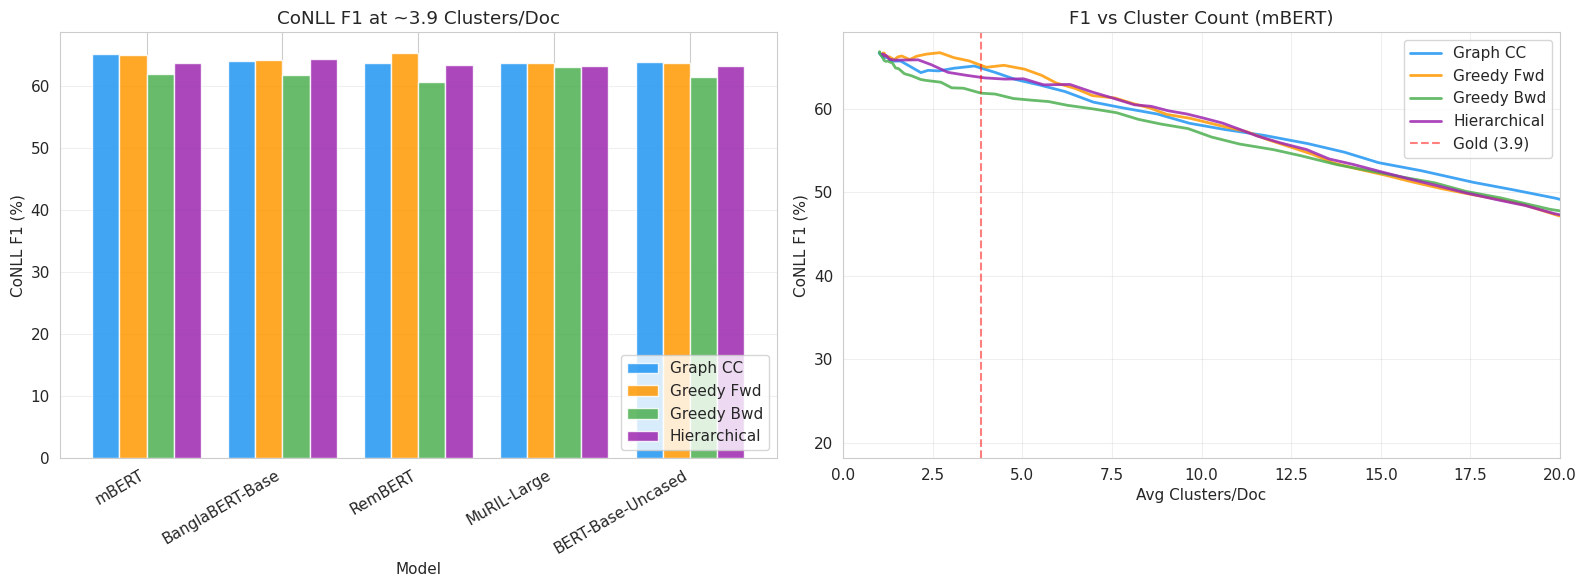

✓ Visualization saved


In [10]:
"""
Cell 9: Visualization - Grouped bar chart and F1 vs clusters curves.
"""

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Grouped bar chart of CoNLL F1 at matched clusters ---
ax = axes[0]
algo_names = ['graph_cc', 'greedy_forward', 'greedy_backward', 'hierarchical_avg']
algo_labels = ['Graph CC', 'Greedy Fwd', 'Greedy Bwd', 'Hierarchical']
model_names = [m.name for m in MODELS]
x = np.arange(len(model_names))
width = 0.2

colors = ['#2196F3', '#FF9800', '#4CAF50', '#9C27B0']

for i, (algo, label, color) in enumerate(zip(algo_names, algo_labels, colors)):
    values = [pivot_f1.loc[m, algo] for m in model_names]
    ax.bar(x + i * width, values, width, label=label, color=color, alpha=0.85)

ax.set_xlabel('Model')
ax.set_ylabel('CoNLL F1 (%)')
ax.set_title(f'CoNLL F1 at ~{GOLD_TARGET_CLUSTERS:.1f} Clusters/Doc')
ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels(model_names, rotation=30, ha='right')
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)

# --- Plot 2: F1 vs Clusters/Doc curves for one representative model ---
ax = axes[1]
# Use mBERT as representative
rep_model = 'mBERT'
for algo, label, color in zip(algo_names, algo_labels, colors):
    subset = df_sweep[(df_sweep['model'] == rep_model) & (df_sweep['algorithm'] == algo)]
    subset = subset.sort_values('avg_clusters_per_doc')
    ax.plot(subset['avg_clusters_per_doc'], subset['CoNLL_F1'], 
            label=label, color=color, linewidth=2, alpha=0.85)

ax.axvline(x=GOLD_TARGET_CLUSTERS, color='red', linestyle='--', alpha=0.5, label=f'Gold ({GOLD_TARGET_CLUSTERS:.1f})')
ax.set_xlabel('Avg Clusters/Doc')
ax.set_ylabel('CoNLL F1 (%)')
ax.set_title(f'F1 vs Cluster Count ({rep_model})')
ax.set_xlim(0, 20)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('clustering_algorithm_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("\u2713 Visualization saved")

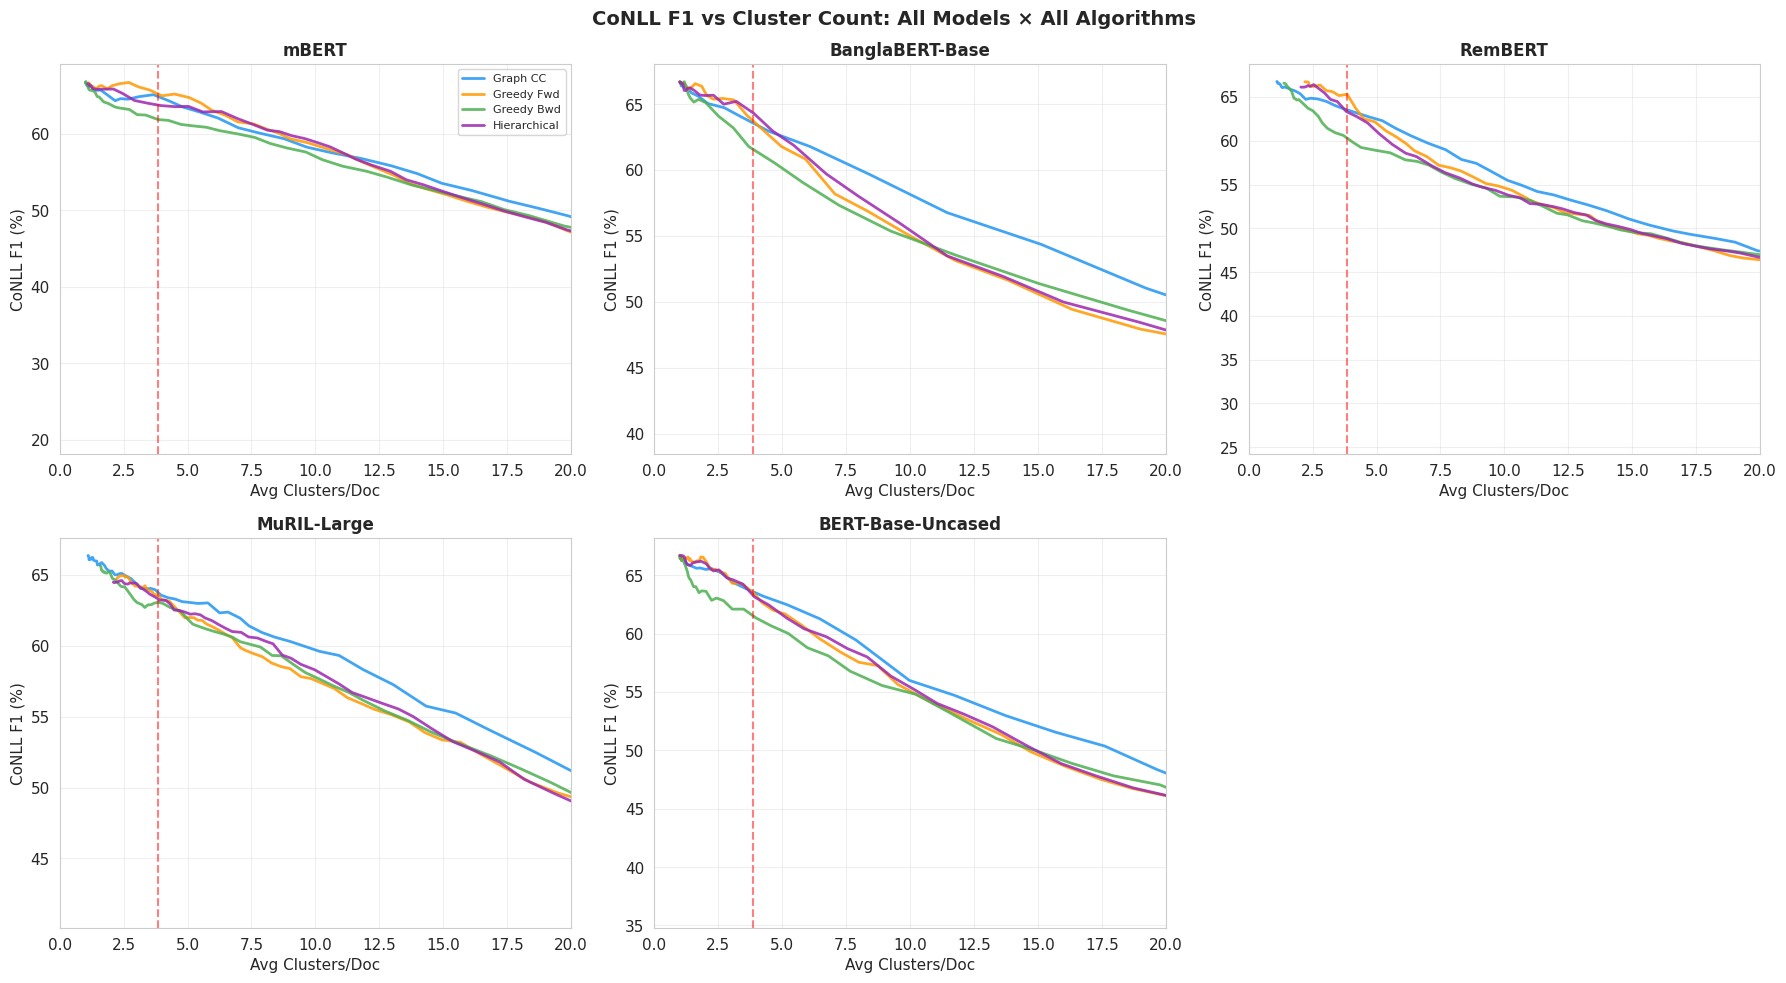

✓ All-models visualization saved


In [11]:
"""
Cell 10: F1 vs Clusters/Doc curves for ALL models (one subplot per model).
"""

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes_flat = axes.flatten()

algo_names = ['graph_cc', 'greedy_forward', 'greedy_backward', 'hierarchical_avg']
algo_labels = ['Graph CC', 'Greedy Fwd', 'Greedy Bwd', 'Hierarchical']
colors = ['#2196F3', '#FF9800', '#4CAF50', '#9C27B0']

for idx, model_config in enumerate(MODELS):
    ax = axes_flat[idx]
    model_name = model_config.name
    
    for algo, label, color in zip(algo_names, algo_labels, colors):
        subset = df_sweep[(df_sweep['model'] == model_name) & (df_sweep['algorithm'] == algo)]
        subset = subset.sort_values('avg_clusters_per_doc')
        ax.plot(subset['avg_clusters_per_doc'], subset['CoNLL_F1'],
                label=label, color=color, linewidth=2, alpha=0.85)
    
    ax.axvline(x=GOLD_TARGET_CLUSTERS, color='red', linestyle='--', alpha=0.5)
    ax.set_title(model_name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Avg Clusters/Doc')
    ax.set_ylabel('CoNLL F1 (%)')
    ax.set_xlim(0, 20)
    ax.grid(alpha=0.3)
    if idx == 0:
        ax.legend(fontsize=8)

# Hide unused subplot
axes_flat[5].set_visible(False)

plt.suptitle('CoNLL F1 vs Cluster Count: All Models × All Algorithms', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('all_models_algorithm_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("\u2713 All-models visualization saved")

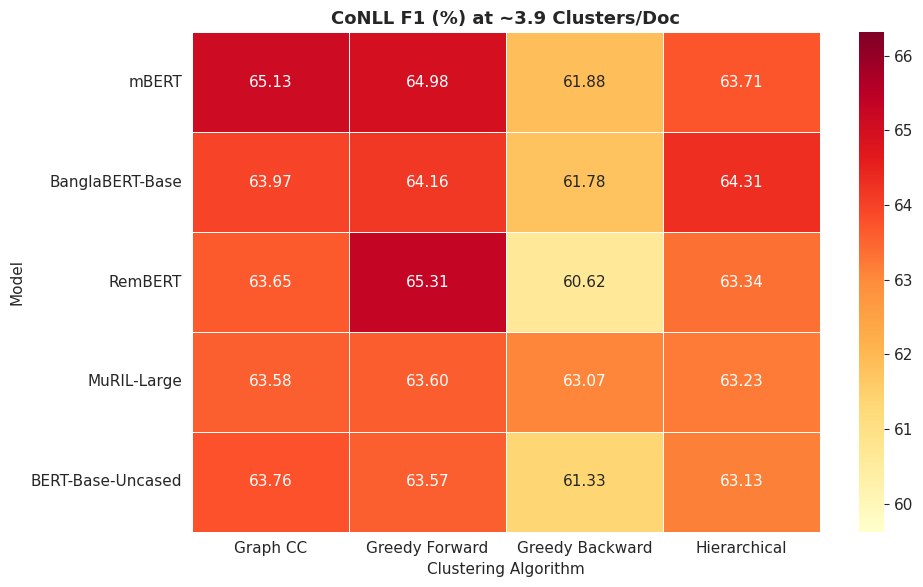

✓ Heatmap saved


In [12]:
"""
Cell 11: Heatmap of CoNLL F1 at cluster-matched thresholds.
"""

fig, ax = plt.subplots(figsize=(10, 6))

# Rename for display
display_df = pivot_f1.copy()
display_df.columns = ['Graph CC', 'Greedy Forward', 'Greedy Backward', 'Hierarchical']

sns.heatmap(display_df, annot=True, fmt='.2f', cmap='YlOrRd', 
            linewidths=0.5, ax=ax, vmin=display_df.values.min() - 1,
            vmax=display_df.values.max() + 1)

ax.set_title(f'CoNLL F1 (%) at ~{GOLD_TARGET_CLUSTERS:.1f} Clusters/Doc', fontsize=13, fontweight='bold')
ax.set_ylabel('Model')
ax.set_xlabel('Clustering Algorithm')

plt.tight_layout()
plt.savefig('algorithm_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("\u2713 Heatmap saved")

In [13]:
"""
Cell 12: Statistical significance - paired comparison.

For each model, do a document-level paired comparison between algorithms
at their cluster-matched thresholds.

This gives us per-document F1 differences, not just averages.
"""

from scipy import stats

print("=" * 80)
print("DOCUMENT-LEVEL PAIRED COMPARISON")
print("=" * 80)

# For each model, get per-document CoNLL F1 at the cluster-matched threshold for each algorithm
doc_level_results = {}  # (model, algorithm) -> list of per-doc CoNLL F1

for _, row in df_matched.iterrows():
    model_name = row['model']
    algo_name = row['algorithm']
    threshold = row['threshold']
    
    algo_fn = ALGORITHMS[algo_name]['fn']
    sim_matrices = all_sim_matrices[model_name]
    
    per_doc_f1 = []
    for doc_idx, doc in enumerate(bencoref_data):
        sim_matrix = sim_matrices[doc_idx]
        if sim_matrix.size == 0:
            per_doc_f1.append(0.0)
            continue
        pred_clusters = algo_fn(sim_matrix, threshold)
        metrics = CorefMetrics.evaluate(doc['clusters'], pred_clusters)
        per_doc_f1.append(metrics['CoNLL_F1'])
    
    doc_level_results[(model_name, algo_name)] = per_doc_f1

# Paired t-tests: graph_cc vs each other algorithm, per model
algo_pairs = [('graph_cc', 'greedy_forward'), ('graph_cc', 'greedy_backward'), ('graph_cc', 'hierarchical_avg')]

print("\nPaired t-test: graph_cc vs each alternative (per model, N=122 docs)")
print("-" * 80)

for model_config in MODELS:
    model_name = model_config.name
    print(f"\n  {model_name}:")
    
    gc_scores = doc_level_results[(model_name, 'graph_cc')]
    
    for algo_a, algo_b in algo_pairs:
        other_scores = doc_level_results[(model_name, algo_b)]
        
        diff = np.array(gc_scores) - np.array(other_scores)
        mean_diff = np.mean(diff)
        
        t_stat, p_value = stats.ttest_rel(gc_scores, other_scores)
        sig = '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'ns'
        
        direction = '+' if mean_diff > 0 else '-'
        print(f"    vs {algo_b:<20s}: \u0394={direction}{abs(mean_diff):.2f}pp, t={t_stat:.2f}, p={p_value:.4f} {sig}")

# Also: wins/ties/losses across all 5 models
print("\n" + "=" * 80)
print("ALGORITHM WIN COUNT (best CoNLL F1 per model):")
print("=" * 80)
win_counts = defaultdict(int)
for model_name in [m.name for m in MODELS]:
    best_algo = pivot_f1.loc[model_name].idxmax()
    win_counts[best_algo] += 1
for algo in ['graph_cc', 'greedy_forward', 'greedy_backward', 'hierarchical_avg']:
    print(f"  {algo:<25s}: {win_counts[algo]} / {len(MODELS)} models")

print("\n\u2713 Statistical comparison complete")

DOCUMENT-LEVEL PAIRED COMPARISON

Paired t-test: graph_cc vs each alternative (per model, N=122 docs)
--------------------------------------------------------------------------------

  mBERT:
    vs greedy_forward      : Δ=+0.15pp, t=0.16, p=0.8727 ns
    vs greedy_backward     : Δ=+3.25pp, t=3.55, p=0.0006 ***
    vs hierarchical_avg    : Δ=+1.42pp, t=1.61, p=0.1108 ns

  BanglaBERT-Base:
    vs greedy_forward      : Δ=-0.19pp, t=-0.31, p=0.7582 ns
    vs greedy_backward     : Δ=+2.19pp, t=3.55, p=0.0005 ***
    vs hierarchical_avg    : Δ=-0.35pp, t=-0.73, p=0.4648 ns

  RemBERT:
    vs greedy_forward      : Δ=-1.66pp, t=-2.03, p=0.0441 *
    vs greedy_backward     : Δ=+3.03pp, t=3.81, p=0.0002 ***
    vs hierarchical_avg    : Δ=+0.31pp, t=0.49, p=0.6224 ns

  MuRIL-Large:
    vs greedy_forward      : Δ=-0.02pp, t=-0.03, p=0.9736 ns
    vs greedy_backward     : Δ=+0.51pp, t=1.10, p=0.2736 ns
    vs hierarchical_avg    : Δ=+0.35pp, t=0.76, p=0.4469 ns

  BERT-Base-Uncased:
    vs gree

In [14]:
"""
Cell 13: Final Summary and Conclusion.
"""

print("=" * 80)
print("CLUSTERING ALGORITHM COMPARISON - FINAL SUMMARY")
print("=" * 80)

print(f"\nExperiment: 5 models \u00d7 4 algorithms \u00d7 {len(SIM_THRESHOLDS)} thresholds")
print(f"Dataset: BenCoref (122 documents, 4 domains)")
print(f"Matching criterion: avg clusters/doc \u2248 {GOLD_TARGET_CLUSTERS:.2f} (gold standard)")

print("\n--- Results at Cluster-Matched Thresholds ---")
print(pivot_f1.round(2).to_string())

print("\n--- Average Across Models ---")
avg_by_algo = pivot_f1.mean()
for algo in avg_by_algo.sort_values(ascending=False).index:
    print(f"  {algo:<25s}: {avg_by_algo[algo]:.2f}%")

print("\n" + "=" * 80)
best = avg_by_algo.idxmax()
second = avg_by_algo.sort_values(ascending=False).index[1]
gap = avg_by_algo[best] - avg_by_algo[second]
print(f"CONCLUSION: {best} is {'best' if gap > 0.5 else 'marginally best'} overall")
print(f"  Gap to 2nd ({second}): {gap:.2f} percentage points")
if gap < 0.5:
    print(f"  Note: Differences are small - algorithm choice is a justified design decision,")
    print(f"  not a major performance factor.")
print("=" * 80)

CLUSTERING ALGORITHM COMPARISON - FINAL SUMMARY

Experiment: 5 models × 4 algorithms × 66 thresholds
Dataset: BenCoref (122 documents, 4 domains)
Matching criterion: avg clusters/doc ≈ 3.85 (gold standard)

--- Results at Cluster-Matched Thresholds ---
algorithm          graph_cc  greedy_forward  greedy_backward  hierarchical_avg
model                                                                         
mBERT                 65.13           64.98            61.88             63.71
BanglaBERT-Base       63.97           64.16            61.78             64.31
RemBERT               63.65           65.31            60.62             63.34
MuRIL-Large           63.58           63.60            63.07             63.23
BERT-Base-Uncased     63.76           63.57            61.33             63.13

--- Average Across Models ---
  greedy_forward           : 64.32%
  graph_cc                 : 64.02%
  hierarchical_avg         : 63.54%
  greedy_backward          : 61.74%

CONCLUSION: greedy